In [1]:
#1
%matplotlib inline 
%load_ext autoreload
%autoreload 2

import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
import helper_functions as hlp

# torch.manual_seed(42)
torch.set_default_dtype(torch.float64)


T = 60e-6           
B = 2e6             
Fs = 5 * B          
N = int(np.round(T * Fs)) 

N_fft = 2**14


t_np = np.linspace(0, T, N, endpoint=False)
t = torch.tensor(t_np, dtype=torch.float64)

t_norm = t / torch.max(t)

b_slope = B/T
psi = 2 * np.pi * (b_slope/2) * t**2
a = 1
s_base = a * torch.complex(torch.cos(psi), torch.sin(psi))
s_base_np = np.array(s_base)

 
# Nulls real frequencies for N_FFT = 2**14
null_targets = np.arange(0e6, 2e6, 0.125e6)
nulls = []

for f_val in null_targets:
    df = Fs / N_fft
    bin_idx = int(np.round(f_val / df))
    nulls.append(bin_idx * df)

from OFDM_2 import OFDM_freqs
# OFDM frequencies
nulls = OFDM_freqs(16, T=T)

null_freqs = nulls





print(f"Targets defined at: {[f/1e6 for f in null_freqs]} MHz")


# Steering Matrix
steering_vectors = []
for f in null_freqs:
    w = 2 * np.pi * f
    vec = torch.complex(torch.cos(w * t), -torch.sin(w * t))
    steering_vectors.append(vec)

steering_matrix = torch.stack(steering_vectors)


z = torch.tensor(hlp.build_z(a,psi,t,null_freqs))


Targets defined at: [np.float64(0.0), np.float64(0.016666666666666666), np.float64(0.03333333333333333), np.float64(0.05), np.float64(0.06666666666666667), np.float64(0.08333333333333333), np.float64(0.1), np.float64(0.11666666666666665), np.float64(0.13333333333333333), np.float64(0.15), np.float64(0.16666666666666666), np.float64(0.18333333333333335), np.float64(0.2), np.float64(0.21666666666666665), np.float64(0.2333333333333333), np.float64(0.25)] MHz


In [2]:
from version1 import getphi
phi_start =  torch.tensor(getphi(null_freqs), dtype=torch.float64, requires_grad=True)
phi_start = phi_start.squeeze()

s_lin = s_base * torch.exp(1j * phi_start)


Null at around 0.40 MHz: Depth = -39.80 dB


C:\Users\Elad\AppData\Local\Temp\ipykernel_11476\2260385377.py:2: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Copy.cpp:307.)
  phi_start =  torch.tensor(getphi(null_freqs), dtype=torch.float64, requires_grad=True)


In [3]:
# יצירת וקטור רנדומלי בטווח [15 ,15-]
phi_start = (30 * torch.rand(600, dtype=torch.float64) - 15).detach().requires_grad_(True)
#phi_start = torch.zeros(N, dtype=torch.float64, requires_grad=True)
print("initial_phi_shape:", phi_start.shape)


initial_phi_shape: torch.Size([600])


In [4]:
def calculate_mf_pslr_islr_torch(signal, db=False):
    
    matched_filter = torch.conj(torch.flip(signal, dims=[0]))
    
    conv_len = signal.shape[0] + matched_filter.shape[0] - 1
    mf = torch.fft.ifft(torch.fft.fft(signal, n=conv_len) * torch.fft.fft(matched_filter, n=conv_len))
    

    mf_abs = torch.abs(mf)
    mf_db = 20 * torch.log10(mf_abs + 1e-20)
    
    # PSLR Calculation
    center_idx = torch.argmax(mf_db)
    main_lobe_width_seconds = 2 / B
    margin_samples = int((main_lobe_width_seconds / 2) * Fs)
    left_side = mf_db[:center_idx - margin_samples]
    right_side = mf_db[center_idx + margin_samples:]

    mainlobe_region = mf_db[center_idx - margin_samples:center_idx + margin_samples]
    sidelobe_region = torch.cat((left_side, right_side))

    max_sidelobe_db = torch.max(sidelobe_region)
    max_mainlobe_db = torch.max(mainlobe_region)

    # ISLR calculation 
    n_main = torch.arange(len(mf_db[center_idx - margin_samples : center_idx + margin_samples]), dtype=mf_abs.dtype, device=mf_abs.device)
    n_left = torch.arange(len(left_side), dtype=mf_abs.dtype, device=mf_abs.device)
    n_right = torch.arange(len(right_side), dtype=mf_abs.dtype, device=mf_abs.device)
    
    main_lobe_linear = mf_abs[center_idx - margin_samples : center_idx + margin_samples]
    left_side_linear = mf_abs[:center_idx - margin_samples]
    right_side_linear = mf_abs[center_idx + margin_samples:] 

    main_lobe_energy = torch.trapezoid(main_lobe_linear ** 2, x=n_main)
    sidelobe_energy = torch.trapezoid(left_side_linear ** 2, x=n_left) + torch.trapezoid(right_side_linear ** 2, x=n_right)
    
    if db:
        # PSLR כערך שלילי (Sidelobe vs Mainlobe)
        pslr = max_sidelobe_db - max_mainlobe_db
        islr = 10 * torch.log10(sidelobe_energy / (main_lobe_energy + 1e-40))
    else:
        # בחישוב ליניארי - עבודה ישירה עם הערכים הליניאריים
        sidelobes = torch.cat((left_side_linear, right_side_linear))
        p = 10 
        # מחליף את ה-torch.max המסורתי
        # max_sidelobe_linear = torch.sum(sidelobes ** p) ** (1/p)
        max_sidelobe_linear = torch.max(torch.cat((left_side_linear, right_side_linear)))
        max_mainlobe_linear = torch.max(main_lobe_linear)
        
        pslr = max_sidelobe_linear / (max_mainlobe_linear + 1e-40)
        pslr = pslr**2
        islr = sidelobe_energy / (main_lobe_energy + 1e-40)
        


    return mf_db, pslr, islr

    #TODO change len()/2 to max or argmax 

In [5]:
# 2
import copy 
iterations = 5000
phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)

# Check that phi has the correct shape
if phi.shape != (N,):
    raise ValueError(f"Expected phi to have shape ({N},), but got {phi.shape}")

lr = 0.108
beta_nulls = 1 # 0.602593 #2.315
beta_smooth = 1
beta_norm = 1
beta_pslr = 1    # 4.962711
beta_islr = 1    # 4.8348218
beta_div1 = 0
beta_div2 = 0

# one null:
norm_norm =1/12.377391138907695
norm_div1 =1/0.000978264127076254
norm_div2 =1/0.000861558612898089
norm_nulls =1/0.46179487055553126
norm_pslr =1/0.04657709046394562
norm_islr =1/0.11674486206525744
norm_smooth =1/3.3783233686063587

# Three nulls:
# norm_norm =1/41.555595426917236
# norm_div1 =1/0.005039421305603246
# norm_div2 =1/0.0038478168480758955
# norm_nulls =1/8.111510554855288
# norm_pslr =1/0.05207834588357033
# norm_islr =1/0.1781185939511803
# norm_smooth =1/15.93282108899966


optimizer = torch.optim.Adam([phi], lr=lr)
print(f"Starting Multi-Null Optimization ({iterations} iterations)...")
print(f"Saving best model based on Minimum Total Loss (Energy + Regularization)")

loss_history = []


best_loss = float('inf') 
best_phi = None
best_epoch = 0

for i in range(iterations):
    
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_transmit = s_base * correction_phasor
    
   
    spectral_vals = torch.matmul(steering_matrix, s_transmit)
    energies = torch.abs(spectral_vals)**2
    
    
    loss_nulls = beta_nulls * torch.sum(energies) *  norm_nulls
    
    diff_phi = phi[1:] - phi[:-1]
    loss_smooth = beta_smooth * torch.sum(diff_phi**2) * norm_smooth
    
    
    loss_norm = beta_norm * torch.sum(phi**2) * norm_norm

    if beta_div1 > 0 or beta_div2 > 0:
        integrals1 = [
            (1/((60*10**-6)**2))*torch.trapezoid(z[:, k] * correction_phasor * t, x=t) 
            for k in range(z.shape[1])
        ]
        
        loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])*norm_div1


        integrals2 = [
            (1/((60*10**-6)**3))*torch.trapezoid(z[:, k] * correction_phasor * (t**2), x=t) 
            for k in range(z.shape[1])
        ]
        loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])*norm_div2
    else:
        loss_div1 = 0
        loss_div2 = 0
    
    mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, False)

    
    loss_pslr = beta_pslr * pslr*norm_pslr
    loss_islr = beta_islr * islr *norm_islr



    loss = loss_norm  + loss_div1 + loss_div2  + loss_nulls + loss_pslr + loss_islr + loss_smooth
    #loss = torch.max(torch.stack([loss_norm, loss_div1, loss_div2, loss_nulls, loss_pslr, loss_islr, loss_smooth]))

    
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_phi = phi.clone() 
        best_epoch = i
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    
    if i % 1000 == 0:
        print(f"Iter {i}: Total Loss = {loss.item():.6f}")
       
        max_depth = 10 * np.log10(torch.max(energies).item() + 1e-40)
        print(f"   Worst Null Depth: {max_depth:.2f} dB")

print("\n--- Optimization Finished ---")
print(f"Restoring best model from Epoch {best_epoch} (Total Loss: {best_loss:.6f})")



with torch.no_grad():
    phi.copy_(best_phi)



final_spectral = torch.matmul(steering_matrix, s_base * torch.complex(torch.cos(phi), torch.sin(phi)))
final_energies = torch.abs(final_spectral)**2
print("Null Depths in Selected Model:")
for k, f in enumerate(null_freqs):

    e_db = 10 * np.log10(final_energies[k].item())
    print(f"Freq {f/1e6} MHz: {e_db:.2f} dB")


C:\Users\Elad\AppData\Local\Temp\ipykernel_11476\485198195.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)


Starting Multi-Null Optimization (5000 iterations)...
Saving best model based on Minimum Total Loss (Energy + Regularization)
Iter 0: Total Loss = 58137.980344
   Worst Null Depth: 34.38 dB
Iter 1000: Total Loss = 176.503423
   Worst Null Depth: -31.10 dB
Iter 2000: Total Loss = 27.915299
   Worst Null Depth: -35.62 dB
Iter 3000: Total Loss = 23.358906
   Worst Null Depth: -15.03 dB
Iter 4000: Total Loss = 25.950003
   Worst Null Depth: -4.47 dB

--- Optimization Finished ---
Restoring best model from Epoch 4746 (Total Loss: 22.885857)
Null Depths in Selected Model:
Freq 0.0 MHz: -21.65 dB
Freq 0.016666666666666666 MHz: -18.16 dB
Freq 0.03333333333333333 MHz: -20.52 dB
Freq 0.05 MHz: -21.93 dB
Freq 0.06666666666666667 MHz: -14.05 dB
Freq 0.08333333333333333 MHz: -16.42 dB
Freq 0.1 MHz: -20.95 dB
Freq 0.11666666666666665 MHz: -26.61 dB
Freq 0.13333333333333333 MHz: -19.56 dB
Freq 0.15 MHz: -12.64 dB
Freq 0.16666666666666666 MHz: -22.26 dB
Freq 0.18333333333333335 MHz: -21.52 dB
Freq 0.2

--- True Null Depths (Calculated Mathematically) ---
Freq 0.0 MHz: -57.89 dB
Freq 0.016666666666666666 MHz: -54.40 dB
Freq 0.03333333333333333 MHz: -56.76 dB
Freq 0.05 MHz: -58.17 dB
Freq 0.06666666666666667 MHz: -50.28 dB
Freq 0.08333333333333333 MHz: -52.66 dB
Freq 0.1 MHz: -57.19 dB
Freq 0.11666666666666665 MHz: -62.85 dB
Freq 0.13333333333333333 MHz: -55.80 dB
Freq 0.15 MHz: -48.88 dB
Freq 0.16666666666666666 MHz: -58.50 dB
Freq 0.18333333333333335 MHz: -57.76 dB
Freq 0.2 MHz: -65.13 dB
Freq 0.21666666666666665 MHz: -59.89 dB
Freq 0.2333333333333333 MHz: -51.35 dB
Freq 0.25 MHz: -50.89 dB


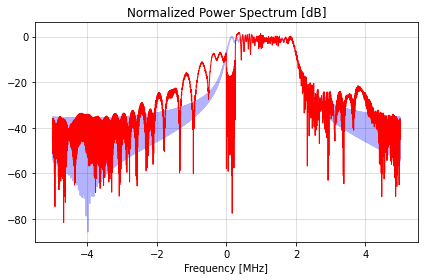

In [6]:
#3 Showing the Null
null_freqs_np = np.array(null_freqs) 


with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(best_phi), torch.sin(best_phi))
    s_transmit_best = s_base * correction_phasor
    
    phi_learned = best_phi.detach().cpu().numpy()
    s_final_np = s_transmit_best.detach().cpu().numpy()


freqs = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/Fs))


S_orig = np.fft.fftshift(np.fft.fft(s_base.numpy(), n=N_fft))
S_final = np.fft.fftshift(np.fft.fft(s_final_np, n=N_fft))


S_orig_db = 20*np.log10(np.abs(S_orig) + 1e-15)
S_final_db = 20*np.log10(np.abs(S_final) + 1e-15)


peak_ref = np.max(S_orig_db)
S_orig_norm = S_orig_db - peak_ref
S_final_norm = S_final_db - peak_ref


with torch.no_grad():
    # חישוב ב-PyTorch
    exact_vals = torch.matmul(steering_matrix, s_transmit_best)
    energies_torch = torch.abs(exact_vals)**2
    
    # המרה מסודרת ל-Numpy
    energies_np = energies_torch.detach().cpu().numpy()
    
    # חישוב dB ב-Numpy
    exact_db_absolute = 10 * np.log10(energies_np + 1e-40)
    
    # נרמול
    exact_db_relative = exact_db_absolute - peak_ref

print("--- True Null Depths (Calculated Mathematically) ---")
for k, f_val in enumerate(null_freqs_np):
    print(f"Freq {f_val/1e6} MHz: {exact_db_relative[k]:.2f} dB")


# 5. הציור
plt.figure()

# גרף האות המקורי
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue', alpha=0.3) # original signal

# גרף האות האופטימלי (FFT)
plt.plot(freqs/1e6, S_final_norm, label='Optimized Signal', color='red', linewidth=1) # optimized signal

# stars for exact null depths
# plt.scatter(null_freqs_np/1e6, exact_db_relative, 
#             color='black', marker='*', s=150, zorder=10, 
#             label='Exact Analytical Depth')
# 
# # adding text next to stars
# for k, f_val in enumerate(null_freqs_np):
#     depth = exact_db_relative[k]
#     plt.text(f_val/1e6, depth - 5, f"{depth:.1f} dB", 
#              color='black', fontweight='bold', ha='center', fontsize=9)

plt.title("Normalized Power Spectrum [dB]")
plt.xlabel("Frequency [MHz]")

#plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)
# plt.xlim(-0.5, 0.5)
# plt.ylim(-78, 5)
plt.tight_layout()
plt.show()

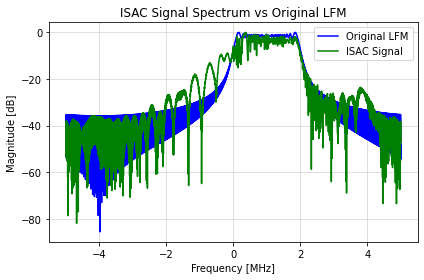

In [7]:
# OFDM signal generation
from OFDM_2 import OFDM, OFDM_demodulate
import OFDM_2

def QPSK_modulation(bits):
    """ Modulate the input bits using QPSK modulation. """
    if len(bits) % 2 != 0:
        raise ValueError("Number of bits must be even for QPSK modulation.")
    
    # bits generate
    bit_pairs = bits.reshape(-1, 2)

    # bits to QPSK symbols conversion
    symbols = np.zeros(len(bit_pairs), dtype=complex)
    for i, pair in enumerate(bit_pairs):
        if np.array_equal(pair, [0, 0]):
            symbols[i] = 1 + 1j
        elif np.array_equal(pair, [0, 1]):
            symbols[i] = 1 - 1j
        elif np.array_equal(pair, [1, 0]):
            symbols[i] = -1 + 1j
        elif np.array_equal(pair, [1, 1]):
            symbols[i] = -1 - 1j
    return symbols/np.sqrt(2) # return normalized bits

bits = np.random.randint(0, 2, 16*2)
QPSK_data = QPSK_modulation(bits)

OFDM_signal = OFDM(QPSK_data, t=t, num=16, normalize=True)
isac_signal = s_final_np + OFDM_signal

ISAC_freqs, ISAC_SIGNAL = hlp.spectrum(isac_signal, Fs, 2**14)

S_isac_db = 20*np.log10(np.abs(ISAC_SIGNAL) + 1e-15)
S_isac_norm = 20*np.log10(np.abs(ISAC_SIGNAL)/np.max(np.abs(ISAC_SIGNAL)) + 1e-400)

# plotting results in the frequency domain
plt.figure()
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue')
plt.plot(ISAC_freqs/1e6, S_isac_norm, label='ISAC Signal', color='green')
# plt.plot(freqs/1e6, S_final_norm, label='Final Signal', color='red')
plt.title("ISAC Signal Spectrum vs Original LFM")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Matching Receiver Designation
"""
For now, we assume a non-observable environment.
The Sensing part of the signal will only be checked by the PSLR-ISLR metrics.
"""

def isac_to_data (isac_signal, nulled_chirp, new=True):
    if new:
        return isac_signal
    else:
        return isac_signal - nulled_chirp

def isac_receiver(isac_signal, nulled_chirp):
    r_t = isac_to_data(isac_signal, nulled_chirp)
    return OFDM_2.OFDM_demodulate(r_t, 16)

plt.figure(figsize=(6, 6))

def channel (isac_signal=isac_signal, SNR_val=0, seed=1, num_symbols=16):
    np.random.seed(seed)
    signal_energy = np.abs(np.trapezoid(isac_signal*np.conj(isac_signal))) # energy for signal (16 symbols)
    Es = signal_energy/num_symbols
    #print("mean signal magnitude: ", Es)

    SNR_linear = 10**(SNR_val / 10)
    N0 = Es / SNR_linear
    sigma = np.sqrt(N0 / 2)
    noise = np.random.normal(0, sigma, size=len(isac_signal)) + 1j*np.random.normal(0, sigma, size=len(isac_signal))
    
    # AWGN channel
    r_t = isac_signal + noise

    # print this
    _, R = hlp.spectrum(r_t, Fs, 2**14)
    R_norm= 20*np.log10(np.abs(R)/np.max(np.abs(R)) + 1e-400)

    # plt.figure()
    # plt.plot(freqs/1e6, R_norm, label='received ISAC', color='blue')
    # # plt.plot(freqs/1e6, S_final_norm, label='Final Signal', color='red')
    # plt.title(f"Received ISAC and OFDM for SNR={SNR_val}")
    # plt.xlabel("Frequency [MHz]")
    # plt.ylabel("Magnitude [dB]")
    # plt.legend()
    # plt.grid(True, alpha=0.5)
    # plt.tight_layout()

    return r_t

def receiver (r_t, num=16, T=T, t=t):
    t = np.array(t)
    r_t = np.array(r_t)
    #print("mean of r_t = ", abs(np.mean(r_t)))
    fs = len(t)/T
    z_n = OFDM_demodulate(np.array(r_t), num=16, t=t, T=T) *16
    return np.array(z_n)
print(QPSK_data)
received_symbols = receiver(channel(SNR_val=30), t=t, T=T)

is_different = list(np.abs(QPSK_data - received_symbols) > 0.5)
print("Difference:", is_different)
    
#plt.show()

[ 0.70710678-0.70710678j  0.70710678+0.70710678j  0.70710678-0.70710678j
  0.70710678+0.70710678j  0.70710678-0.70710678j  0.70710678+0.70710678j
  0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
 -0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
 -0.70710678-0.70710678j -0.70710678-0.70710678j -0.70710678-0.70710678j
  0.70710678+0.70710678j]
Difference: [np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]


<Figure size 432x432 with 0 Axes>

Done with SNR=-10
Done with SNR=0
Done with SNR=10
Done with SNR=20
Done with SNR=30
Done with SNR=400


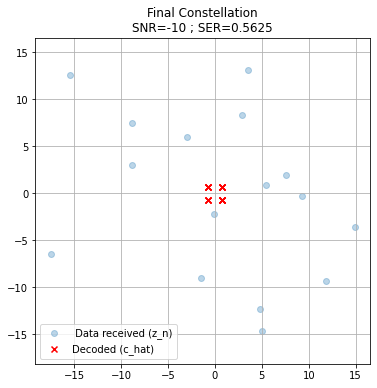

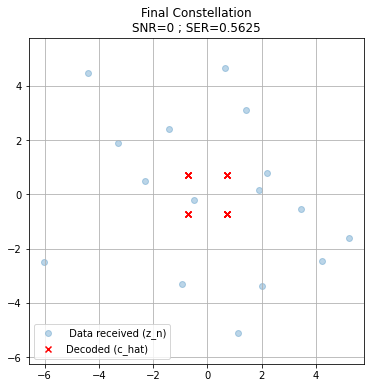

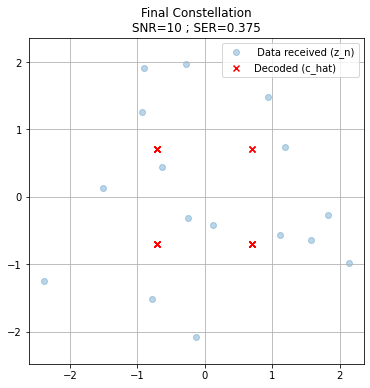

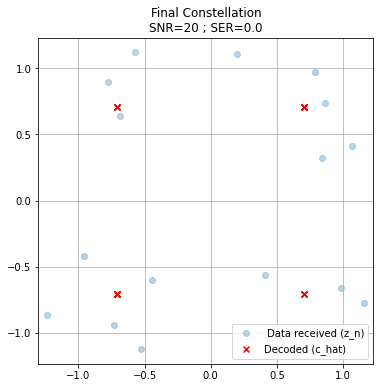

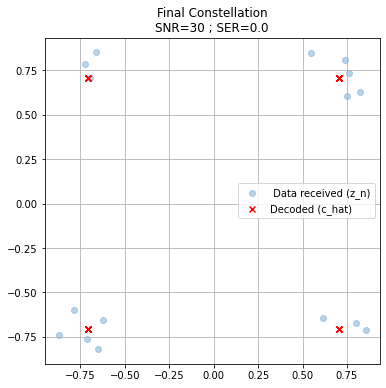

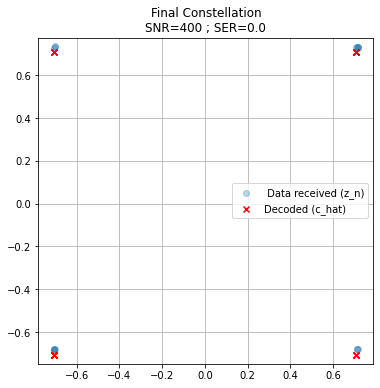

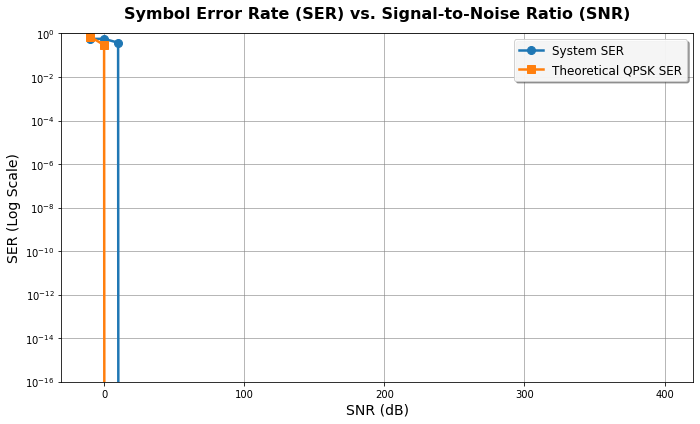

In [ ]:
# Simulating ISAC
from scipy.special import erf

def Q(x):
    return 0.5-0.5*erf(x/np.sqrt(2))

SNR = [-10, -8, -6, -4, -2,  0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]
StC_ratio = [0.5, 1, 2] # Sensing to Communication ratio
sigma = []

SER = []
SER_QAM = []

iteration_count = 5e4

for v, SNR_val in enumerate(SNR):
    equal_num = 0
    data_sent = 0
    seed = 1
    for i in range(int(iteration_count)):
        r_t = channel(isac_signal=isac_signal, SNR_val=SNR_val, seed=seed)
        z_n = receiver(r_t, t=t, T=T)

        real_part = np.where(np.real(z_n) >= 0, 1, -1)
        imag_part = np.where(np.imag(z_n) >= 0, 1, -1)
        c_hat = (real_part + 1j * imag_part) / np.sqrt(2)

        seed +=1
        equal_num += np.sum(np.isclose(QPSK_data, c_hat)) # how many symbols are equal?
        data_sent += len(QPSK_data) # 16 more symbols are sent

        if i % 10000 == 0:
            print("iteration: ", i)
    SER_val = 1- equal_num / data_sent
    if SER_val > 0:
        SER.append(SER_val)
    print(f"Done with SNR={SNR_val}")

    SNR_lin = 10**(SNR_val / 10)
    print(r"$\sqrt(SNR_{lin}) = $" ,np.sqrt(SNR_lin))
    #if 2*Q(np.sqrt(SNR_lin))-(Q(np.sqrt(SNR_lin))**2) > 0:
    SER_QAM.append(2*Q(np.sqrt(SNR_lin))-(Q(np.sqrt(SNR_lin))**2))

    # Plot results
    plt.figure(figsize=(6, 6))
    plt.scatter(np.real(z_n), np.imag(z_n), alpha=0.3, label=' Data received (z_n)')
    plt.scatter(np.real(c_hat), np.imag(c_hat), marker='x', color='r', label='Decoded (c_hat)')
    plt.title(f"Final Constellation\nSNR={SNR_val} ; SER={SER_val}")
    plt.legend()
    plt.grid(True)
    plt.axis('equal')



plt.show()

plt.figure(figsize=(10, 6))

# Semi-log scale (y-axis in log scale)
plt.semilogy(SNR, SER, 
             marker='o',         
             linestyle='-',      
             color='#1f77b4',
             linewidth=2.5,      
             markersize=8,       
             label='System SER')
plt.semilogy(SNR, SER_QAM, 
             marker='s', # Changed marker to distinguish
             linestyle='-', # Changed line style
             color='#ff7f0e', # Changed color to orange
             linewidth=2.5, 
             markersize=8, 
             label='Theoretical QPSK SER')
plt.title('Symbol Error Rate (SER) vs. Signal-to-Noise Ratio (SNR)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('SNR (dB)', fontsize=14)
plt.ylabel('SER (Log Scale)', fontsize=14)
plt.grid(True, which='major', linestyle='-', linewidth=0.8, color='gray', alpha=0.7)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5, color='lightgray', alpha=0.7)
plt.legend(fontsize=12, loc='upper right', framealpha=0.9, shadow=True)
plt.tight_layout()

plt.show()


C:\Users\Elad\AppData\Local\Temp\ipykernel_20512\1188466563.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_base = torch.tensor(s_base).detach().clone()
C:\Users\Elad\AppData\Local\Temp\ipykernel_20512\1188466563.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_lin = torch.tensor(s_lin).detach().clone()


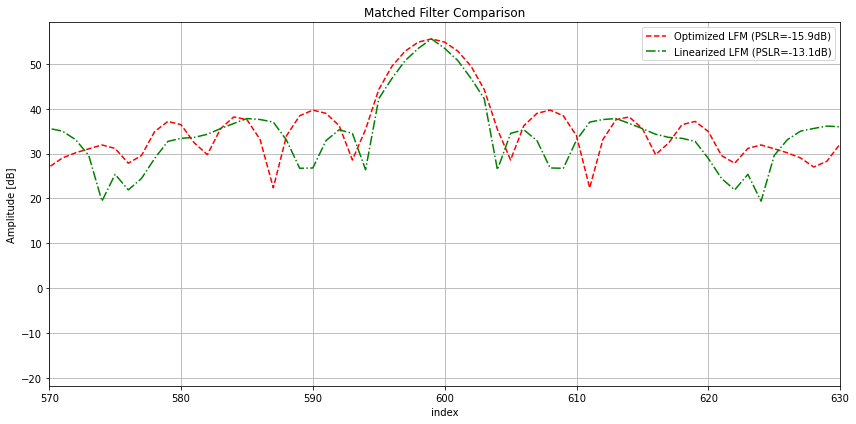

--- PSLR Performence ---
Selected Model based on Minimum Total Loss
Original LFM PSLR:  -13.46 dB
Optimized LFM PSLR: -15.87 dB
Linearized LFM PSLR: -13.15 dB
Degradation:        2.72 dB
Notice, PSLR should be as low as possible, so negative degradation means worse performance.

--- ISLR Performance ---
Original LFM ISLR:  -9.83 dB
Optimized LFM ISLR: -6.46 dB
Linearized LFM ISLR: 1.05 dB
Degradation:        7.51 dB
Notice, ISLR should be as small as possible, so negative degradation means worse performance.



In [ ]:
#4 - Matched Filter and PSLR Calculation
with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_best = s_base * correction_phasor

    s_best_np = s_best.detach().numpy()
    s_base_np = s_base.numpy()

    s_base = torch.tensor(s_base).detach().clone()
    s_lin = torch.tensor(s_lin).detach().clone()

mf_orig_db, pslr_orig, islr_orig = calculate_mf_pslr_islr_torch(s_base,True)
mf_new_db, pslr_new, islr_new = calculate_mf_pslr_islr_torch(s_best,True)
mf_lin_db, pslr_lin, islr_lin = calculate_mf_pslr_islr_torch(s_lin,True)

plt.figure(figsize=(12, 6))
#plt.plot(mf_orig_db, label=f'Original LFM (PSLR={pslr_orig:.1f}dB)', color='blue', alpha=0.6)
plt.plot(mf_new_db, label=f'Optimized LFM (PSLR={pslr_new:.1f}dB)', color='red', linestyle='--')
plt.plot(mf_lin_db, label=f'Linearized LFM (PSLR={pslr_lin:.1f}dB)', color='green', linestyle='-.')
plt.xlim(570, 630)
plt.title("Matched Filter Comparison")
plt.xlabel("index")
plt.ylabel("Amplitude [dB]")
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig("matched_filter_comparison_three_nulls.png", dpi=1000)
plt.show()

print(f"--- PSLR Performence ---")
print(f"Selected Model based on Minimum Total Loss")
print(f"Original LFM PSLR:  {pslr_orig:.2f} dB")
print(f"Optimized LFM PSLR: {pslr_new:.2f} dB")
print(f"Linearized LFM PSLR: {pslr_lin:.2f} dB")
print(f"Degradation:        {pslr_lin - pslr_new:.2f} dB")
print("Notice, PSLR should be as low as possible, so negative degradation means worse performance.\n")


print(f"--- ISLR Performance ---")
print(f"Original LFM ISLR:  {islr_orig:.2f} dB")
print(f"Optimized LFM ISLR: {islr_new:.2f} dB")
print(f"Linearized LFM ISLR: {islr_lin:.2f} dB")
print(f"Degradation:        {islr_lin - islr_new:.2f} dB")
print("Notice, ISLR should be as small as possible, so negative degradation means worse performance.\n")

# lags = np.arange(-len(s_base_np) + 1, len(s_base_np))
# time_lags = (lags / Fs) * 1e6 



In [8]:
#5 Saving phi
phi_numpy = best_phi.detach().cpu().numpy()


correction_phasor = np.exp(1j * phi_numpy)


filename = 'optimal_three_nulls_b1.npy'
np.save(filename, correction_phasor)

print(f"Success! Saved optimized phasor to '{filename}'")
print(f"File shape: {correction_phasor.shape}")

Success! Saved optimized phasor to 'optimal_three_nulls_b1.npy'
File shape: (600,)


In [ ]:
import optuna
import torch

def objective(trial):
    # 1. בחירת בטאות וקצב למידה על ידי אופטונה
    lr = trial.suggest_float("lr", 1e-3, 1, log=True)
    beta_smooth = trial.suggest_float("beta_smooth", 0.1, 5, log=False)
    beta_norm = trial.suggest_float("beta_norm", 0.1, 5, log=False)
    beta_pslr = trial.suggest_float("beta_pslr", 0.1, 5, log=False)
    beta_islr = trial.suggest_float("beta_islr", 0.1, 5, log=False)
    beta_div1 = trial.suggest_float("beta_div1", 0.1, 5, log=False)
    beta_div2 = trial.suggest_float("beta_div2", 0.1, 5, log=False)
    beta_nulls = trial.suggest_float("beta_nulls", 0.1, 10, log=False)

    beta_smooth = trial.suggest_float("beta_smooth", 0.1, 5, log=False)
    beta_norm = trial.suggest_float("beta_norm", 0.1, 5, log=False)
    beta_pslr = trial.suggest_float("beta_pslr", 0.1, 5, log=False)
    beta_islr = trial.suggest_float("beta_islr", 0.1, 5, log=False)
    beta_div1 = trial.suggest_float("beta_div1", 0.1, 5, log=False)
    beta_div2 = trial.suggest_float("beta_div2", 0.1, 5, log=False)
    beta_nulls = trial.suggest_float("beta_nulls", 0.1, 10, log=False)

    # 2. אתחול מחדש של phi לכל ניסוי - קריטי!
    phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([phi], lr=lr)
    
    # 3. קבועי הנרמול הזהים לאלו של הלולאה הראשית
    norm_norm =1/12.377391138907695
    norm_div1 =1/0.000978264127076254
    norm_div2 =1/0.000861558612898089
    norm_nulls =1/0.46179487055553126
    norm_pslr =1/0.04657709046394562
    norm_islr =1/0.11674486206525744
    norm_smooth =1/3.3783233686063587

    best_loss = float('inf') 
    best_phi = None

    # לולאת האימון (השתמש ב-iterations שהגדרת בחוץ, למשל 2500)
    for i in range(1500):
        correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_transmit = s_base * correction_phasor
        
        spectral_vals = torch.matmul(steering_matrix, s_transmit)
        energies = torch.abs(spectral_vals)**2
        loss_nulls = beta_nulls * torch.sum(energies) * norm_nulls
        
        diff_phi = phi[1:] - phi[:-1]
        loss_smooth = beta_smooth * torch.sum(diff_phi**2) * norm_smooth
        
        loss_norm = beta_norm * torch.sum(phi**2) * norm_norm

        if beta_div1 > 0 or beta_div2 > 0:
            integrals1 = [
                (1/((60*10**-6)**2))*torch.trapezoid(z[:, k] * correction_phasor * t, x=t) 
                for k in range(z.shape[1])
            ]
            loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1]) * norm_div1

            integrals2 = [
                (1/((60*10**-6)**3))*torch.trapezoid(z[:, k] * correction_phasor * (t**2), x=t) 
                for k in range(z.shape[1])
            ]
            loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2]) * norm_div2
        else:
            loss_div1 = 0
            loss_div2 = 0
        
        # חישוב לוסים
        mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, False)
        loss_pslr = beta_pslr * pslr * norm_pslr
        loss_islr = beta_islr * islr * norm_islr

        # לוס כללי
        #loss = loss_norm  + loss_div1 + loss_div2  + loss_nulls+ loss_pslr + loss_islr + loss_smooth
        #loss = torch.max(torch.stack([loss_norm, loss_div1, loss_div2, loss_nulls, loss_pslr, loss_islr, loss_smooth]))
        loss_main_objectives = torch.logsumexp(torch.stack([loss_nulls, loss_pslr, loss_islr]), dim=0)
        loss = loss_main_objectives + loss_norm + loss_div1 + loss_div2 + loss_smooth

        # שמירת המודל הכי טוב
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_phi = phi.clone() 
        
        # צעד אופטימיזציה
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # ---------------------------------------------------------
    # 4. חישוב הערכים הסופיים של אופטונה לפי ה-best_phi!
    # ---------------------------------------------------------
    with torch.no_grad():
        best_phasor = torch.complex(torch.cos(best_phi), torch.sin(best_phi))
        s_best = s_base * best_phasor
        
        # חישוב אנרגיית החורים (האמיתית, ללא הנרמול!)
        best_spectral = torch.matmul(steering_matrix, s_best)
        final_null_energy = torch.sum(torch.abs(best_spectral)**2).item()
        
        # חישוב PSLR ו-ISLR
        _, best_pslr, best_islr = calculate_mf_pslr_islr_torch(s_best, False)
        final_pslr_val = best_pslr.item()
        final_islr_val = best_islr.item()

    # מחזירים לאופטונה את הערכים שהיא צריכה למזער
    return final_null_energy, final_pslr_val, final_islr_val


study = optuna.create_study(
    directions=["minimize", "minimize", "minimize"],
    sampler=optuna.samplers.NSGAIISampler(population_size=50)
)
study.optimize(objective, n_trials=250)



[I 2026-03-03 22:33:29,843] A new study created in memory with name: no-name-8f175747-c338-423c-9a8c-0453cf3f6445
C:\Users\Elad\AppData\Local\Temp\ipykernel_1684\326185779.py:16: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

[I 2026-03-03 22:33:38,795] Trial 0 finished with values: [0.003588967418691738, 0.011696208840016695, 0.11561584340039101] and parameters: {'lr': 0.1501948071612816, 'beta_smooth': 2.412470820854122, 'beta_norm': 0.1902370123159155, 'beta_pslr': 1.3591333347508388, 'beta_islr': 3.444219946952827, 'beta_div1': 4.438832815692498, 'beta_div2': 1.6576799395209014, 'beta_nulls': 8.151724242508426}.
[I 2026-03-03 22:33:48,275] Trial 1 finished with values: [0.007746634822428104, 0.011945200164231016, 0.1143936114493909] and parameters: {'lr': 0.026933930337170637, 'beta_smooth': 4.126255847520025, 'beta_norm': 0.36944105

In [6]:
# Ori's Modification

import optuna
import torch
import numpy as np

def objective(trial):
    # 1. אופטונה מחפשת את הטרייד-אוף של ביצועי הרדאר (המטרות)
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    beta_pslr = trial.suggest_float("beta_pslr", 0.1, 5.0)
    beta_islr = trial.suggest_float("beta_islr", 0.1, 5.0)

    # 2. אופטונה שולטת גם ברגולריזציות (כדי למצוא את הגמישות האידיאלית!)
    # שים לב: אנחנו מגבילים את המינימום ל-0.1 או 0.05 כדי למנוע יצירת רעש לא-פיזיקלי
    beta_smooth = trial.suggest_float("beta_smooth", 0.01, 5.0)
    beta_norm = trial.suggest_float("beta_norm", 0.01, 5.0)
    beta_div1 = trial.suggest_float("beta_div1", 0.01, 5.0)
    beta_div2 = trial.suggest_float("beta_div2", 0.01, 5.0)

    # אתחול
    phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([phi], lr=lr)
    
    # 3. קבועי הנרמול הקריטיים
    norm_norm = 1/12.377391138907695
    norm_div1 = 1/0.000978264127076254
    norm_div2 = 1/0.000861558612898089
    norm_nulls = 1/0.46179487055553126
    norm_pslr = 1/0.04657709046394562
    norm_islr = 1/0.11674486206525744
    norm_smooth = 1/3.3783233686063587
    
    for i in range(2000): 
        correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_transmit = s_base * correction_phasor
        
        spectral_vals = torch.matmul(steering_matrix, s_transmit)
        energies = torch.abs(spectral_vals)**2
        loss_nulls = torch.sum(energies) * norm_nulls
        
        diff_phi = phi[1:] - phi[:-1]
        reg_term = beta_smooth * torch.sum(diff_phi**2) * norm_smooth
        loss_norm = beta_norm * torch.sum(phi**2) * norm_norm
        
        if beta_div1 > 0 or beta_div2 > 0:
            integrals1 = [
                torch.trapezoid(z[:, k] * correction_phasor * t_norm, x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1]) * norm_div1

            integrals2 = [
                torch.trapezoid(z[:, k] * correction_phasor * (t_norm**2), x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2]) * norm_div2
        else:
            loss_div1 = 0
            loss_div2 = 0
        
        mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, db=False)
        loss_pslr = beta_pslr * pslr * norm_pslr
        loss_islr = beta_islr * islr * norm_islr

        # סכום כללי שנותן ל-Adam את הלוס המשוקלל החדש
        loss = loss_norm + loss_div1 + loss_div2 + loss_nulls + loss_pslr + loss_islr + reg_term
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # 4. חילוץ התוצאות
    with torch.no_grad():
        final_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_final = s_base * final_phasor
        
        final_spectral = torch.matmul(steering_matrix, s_final)
        final_null_energy_lin = torch.sum(torch.abs(final_spectral)**2).item()
        final_null_db = 10 * np.log10(final_null_energy_lin + 1e-20)
        
        # שימוש ב-True כדי להחזיר PSLR ב-dB אמיתי לחלוטין (מתקן את שגיאת ה-6dB)
        _, final_pslr_db, final_islr_db = calculate_mf_pslr_islr_torch(s_final, db=True)

    # החזרת ערכים בדציבלים מבטיחה שאופטונה תפזר את הנקודות על חזית פרטו יפה ולא רק באזור אחד
    return final_null_db, final_pslr_db.item(), final_islr_db.item()


study = optuna.create_study(directions=["minimize", "minimize", "minimize"])
study.optimize(objective, n_trials=100) # מומלץ מינימום 500 כשנותנים לה כל כך הרבה פרמטרים

[I 2026-03-06 13:22:11,669] A new study created in memory with name: no-name-f27262ca-6bdd-4d53-9300-c194a8d26f1e
C:\Users\Elad\AppData\Local\Temp\ipykernel_3924\2810321841.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
[I 2026-03-06 13:22:29,456] Trial 0 finished with values: [-22.30769250345594, -13.509688384210506, -9.002515764991044] and parameters: {'lr': 0.00016385777555321627, 'beta_pslr': 1.1719969023550572, 'beta_islr': 1.4966813749278782, 'beta_smooth': 4.327603947964407, 'beta_norm': 4.848553121825094, 'beta_div1': 2.273503030666089, 'beta_div2': 2.991145412368517}.
[I 2026-03-06 13:22:41,466] Trial 1 finished with values: [-34.334813772046964, -13.616995646827192, -9.106347822887106] and parameters: {'lr': 0.00012000083403776744, 'beta_pslr': 4.1337

In [8]:
# FINAL VERSION
# 6 Hyperparameter Optimization with Optuna

import optuna
import torch

def objective(trial):
    
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    beta_smooth = trial.suggest_float("beta_smooth", 1e-5, 5, log=False)
    beta_norm = trial.suggest_float("beta_norm", 1e-5, 5, log=False)
    beta_pslr = trial.suggest_float("beta_pslr", 1e-5, 5, log=False)
    beta_islr = trial.suggest_float("beta_islr", 1e-5, 5, log=False)
    beta_div1 = trial.suggest_float("beta_div1", 1e-5, 5, log=False)
    beta_div2 = trial.suggest_float("beta_div2", 1e-5, 5, log=False) 

    phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([phi], lr=lr)
    
    
    for i in range(2000): 
        correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_transmit = s_base * correction_phasor
        
        spectral_vals = torch.matmul(steering_matrix, s_transmit)
        energies = torch.abs(spectral_vals)**2
        
       
        loss_nulls = torch.sum(energies) 
        
        diff_phi = phi[1:] - phi[:-1]
        reg_term = beta_smooth * torch.sum(diff_phi**2)
        loss_norm = beta_norm * torch.sum(phi**2)
        
        
        if beta_div1 > 0 or beta_div2 > 0:
            integrals1 = [
                torch.trapezoid(z[:, k] * correction_phasor * t_norm, x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])

            integrals2 = [
                torch.trapezoid(z[:, k] * correction_phasor * (t_norm**2), x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])
        else:
            loss_div1 = 0
            loss_div2 = 0
        
        
        mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit)
        loss_pslr = beta_pslr * pslr
        loss_islr = beta_islr * islr 

        
        loss = loss_norm + loss_div1 + loss_div2 + loss_nulls + loss_pslr + loss_islr + reg_term
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    
    
    final_null_energy = loss_nulls.item()
    final_pslr_val = pslr.item()
    final_islr_val = islr.item()

    return final_null_energy, final_pslr_val, final_islr_val


study = optuna.create_study(directions=["minimize", "minimize", "minimize"])
study.optimize(objective, n_trials=150)

[I 2026-03-06 12:07:28,830] A new study created in memory with name: no-name-8e490e42-75d1-49c7-a83f-86a779039a4a
C:\Users\Elad\AppData\Local\Temp\ipykernel_11164\2656943554.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
[W 2026-03-06 12:07:28,853] Trial 0 failed with parameters: {'lr': 0.0002267938759279947, 'beta_smooth': 0.5732972372090712, 'beta_norm': 2.031018295896609, 'beta_pslr': 3.288726810519883, 'beta_islr': 0.9246016159054058, 'beta_div1': 1.5760805186452762, 'beta_div2': 0.13069808731866403} because of the following error: AttributeError("partially initialized module 'torch._inductor' has no attribute 'custom_graph_pass' (most likely due to a circular import)").
Traceback (most recent call last):
  File "c:\Users\Elad\AppData\Local\Programs\Python\

AttributeError: partially initialized module 'torch._inductor' has no attribute 'custom_graph_pass' (most likely due to a circular import)

In [11]:
import re
import ast
import optuna
import numpy as np
from optuna.trial import TrialState
from optuna.distributions import FloatDistribution

# 1. יצירת Study חדש וריק שמוגדר למזער את 3 המטרות
study = optuna.create_study(directions=["minimize", "minimize", "minimize"])

# 2. הגדרת ביטוי רגולרי (Regex) לחילוץ הנתונים מהטקסט
pattern = re.compile(r"Trial (\d+) finished with values: \[(.*?)\] and parameters: (\{.*?\})")

# 3. הגדרת התפלגויות הפרמטרים
distributions = {
    "lr": FloatDistribution(1e-4, 1e-1, log=True),
    "beta_nulls": FloatDistribution(0.1, 5.0),
    "beta_pslr": FloatDistribution(0.1, 5.0),
    "beta_islr": FloatDistribution(0.1, 5.0),
}

parsed_trials = 0

# 4. קריאת קובץ הטקסט ושחזור הנתונים
with open('pareto_5000_700_PSLR_ISLR_Nulls.txt', 'r', encoding='utf-8') as f:
    for line in f:
        match = pattern.search(line)
        if match:
            trial_num = int(match.group(1))
            
            # חילוץ הערכים הלינאריים (Nulls, PSLR, ISLR)
            values_str = match.group(2)
            values = [float(v) for v in values_str.split(',')]
            
            # --- התיקון שלך: הוספת 6.08 dB ל-PSLR הלינארי ---
            # values[1] הוא ה-PSLR. 
            values[1] = values[1] * (10 ** (6.08 / 10))
            
            # חילוץ המילון של הפרמטרים
            params_str = match.group(3)
            params = ast.literal_eval(params_str)
            
            # יצירת "ניסוי קפוא" והכנסתו ל-Study
            trial = optuna.trial.create_trial(
                state=TrialState.COMPLETE,
                values=values,
                params=params,
                distributions=distributions
            )
            
            # הכנסתו ל-study
            study.add_trial(trial)
            parsed_trials += 1

print(f"✅ Successfully restored {parsed_trials} trials into the Optuna 'study' object with corrected PSLR!")

[I 2026-03-10 00:00:47,061] A new study created in memory with name: no-name-2918aa07-f3de-4256-aece-107bc4581659


✅ Successfully restored 709 trials into the Optuna 'study' object with corrected PSLR!


In [7]:
# Decision Boundary Option

import optuna
import torch

def objective(trial):
    # 1. בחירת בטאות וקצב למידה על ידי אופטונה (רק למטרות הראשיות!)
    lr = trial.suggest_float("lr", 1e-3, 0.1, log=True)
    beta_nulls = trial.suggest_float("beta_nulls", 0.1, 5.0)
    beta_pslr = trial.suggest_float("beta_pslr", 0.1, 5.0)
    beta_islr = trial.suggest_float("beta_islr", 0.1, 5.0)

    # 2. הרגולריזציות קבועות ל-1 כדי לשמור על צורת האות ולמנוע עיוותים
    beta_smooth = 1.0
    beta_norm = 1.0
    beta_div1 = 1.0
    beta_div2 = 1.0

    # 3. אתחול מחדש של phi לכל ניסוי - קריטי!
    phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([phi], lr=lr)
    
    # 4. קבועי הנרמול הזהים לאלו של הלולאה הראשית
    norm_norm = 1/12.377391138907695
    norm_div1 = 1/0.000978264127076254
    norm_div2 = 1/0.000861558612898089
    norm_nulls = 1/0.46179487055553126
    norm_pslr = 1/0.04657709046394562
    norm_islr = 1/0.11674486206525744
    norm_smooth = 1/3.3783233686063587

    best_loss = float('inf') 
    best_phi = None

    # 5. לולאת האימון 
    for i in range(5000):
        correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_transmit = s_base * correction_phasor
        
        spectral_vals = torch.matmul(steering_matrix, s_transmit)
        energies = torch.abs(spectral_vals)**2
        
        # חישוב לוסים עם הבטאות החדשות
        loss_nulls = beta_nulls * torch.sum(energies) * norm_nulls
        
        diff_phi = phi[1:] - phi[:-1]
        loss_smooth = beta_smooth * torch.sum(diff_phi**2) * norm_smooth
        
        loss_norm = beta_norm * torch.sum(phi**2) * norm_norm

        if beta_div1 > 0 or beta_div2 > 0:
            integrals1 = [
                (1/((60*10**-6)**2))*torch.trapezoid(z[:, k] * correction_phasor * t, x=t) 
                for k in range(z.shape[1])
            ]
            loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1]) * norm_div1

            integrals2 = [
                (1/((60*10**-6)**3))*torch.trapezoid(z[:, k] * correction_phasor * (t**2), x=t) 
                for k in range(z.shape[1])
            ]
            loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2]) * norm_div2
        else:
            loss_div1 = 0
            loss_div2 = 0
        
        # חישוב מטרות אונות צד
        mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, False)
        loss_pslr = beta_pslr * pslr * norm_pslr
        loss_islr = beta_islr * islr * norm_islr

        # 6. לוס כללי (סכום רגיל - הכל מנורמל אז הכל יקבל גרדיאנטים נכון)
        loss = loss_nulls + loss_pslr + loss_islr + loss_norm + loss_div1 + loss_div2 + loss_smooth

        # שמירת המודל הכי טוב
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_phi = phi.clone() 
        
        # צעד אופטימיזציה
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # ---------------------------------------------------------
    # 7. חישוב הערכים הסופיים של אופטונה לפי ה-best_phi
    # ---------------------------------------------------------
    with torch.no_grad():
        best_phasor = torch.complex(torch.cos(best_phi), torch.sin(best_phi))
        s_best = s_base * best_phasor
        
        # חישוב אנרגיית החורים (האמיתית, ללא הנרמול)
        best_spectral = torch.matmul(steering_matrix, s_best)
        final_null_energy = torch.sum(torch.abs(best_spectral)**2).item()
        
        # חישוב PSLR ו-ISLR
        _, best_pslr, best_islr = calculate_mf_pslr_islr_torch(s_best, False)
        final_pslr_val = best_pslr.item()
        final_islr_val = best_islr.item()

    # מחזירים לאופטונה את הערכים האמיתיים שהיא צריכה למזער (ללא רגולריזציות)
    return final_null_energy, final_pslr_val, final_islr_val


# הפעלת המחקר עם אבולוציה של 250 ריצות לפחות
study = optuna.create_study(
    directions=["minimize", "minimize", "minimize"],
    sampler=optuna.samplers.NSGAIISampler(population_size=50)
)
study.optimize(objective, n_trials=1000)

[I 2026-03-09 18:15:28,891] A new study created in memory with name: no-name-95133ae0-f5eb-4f95-baf3-7e1e8bbbf73c
C:\Users\Elad\AppData\Local\Temp\ipykernel_18412\3605936539.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
[I 2026-03-09 18:16:03,620] Trial 0 finished with values: [3.734748049818031e-05, 0.035044686074149886, 0.08532595606301342] and parameters: {'lr': 0.06707163489733067, 'beta_nulls': 4.3796307924393805, 'beta_pslr': 3.7821461510191163, 'beta_islr': 4.029999560119943}.
[I 2026-03-09 18:16:36,994] Trial 1 finished with values: [3.150399486721792e-05, 0.03786450272217342, 0.08978839744176033] and parameters: {'lr': 0.004859151824801299, 'beta_nulls': 4.028329535887014, 'beta_pslr': 1.7447701669950682, 'beta_islr': 3.9018080001545803}.
[I 2026-03-0

KeyboardInterrupt: 

In [12]:
# Ploting Optuna
import optuna.visualization as vis

fig = vis.plot_pareto_front(
    study, 
    target_names=["Null Energy (Min)", "PSLR ", "ISLR (Min)"]
)
fig.show()
import numpy as np

# 1. יצירת הגרף המקורי של אופטונה (הכותרות כבר עם [dB])
fig1 = vis.plot_pareto_front(
    study, 
    target_names=["Null Energy [dB]", "PSLR [dB]", "ISLR [dB]"],
    include_dominated_trials=False
)
fig1.show()
# 2. המרת כל הנתונים של שלושת הצירים ל-dB
for trace in fig1.data:
    # ציר X: אנרגיית החורים (Nulls)
    if trace.x is not None:
        trace.x = 10 * np.log10(np.array(trace.x, dtype=float) + 1e-20)
        
    # ציר Y: המדד השני (PSLR)
    if trace.y is not None:
        trace.y = 10 * np.log10(np.array(trace.y, dtype=float) + 1e-20)
        
    # ציר Z: המדד השלישי (ISLR)
    if trace.z is not None:
        trace.z = 10 * np.log10(np.array(trace.z, dtype=float) + 1e-20)

# 3. עדכון התצוגה התלת-מימדית כדי שהצירים יהיו ברורים
fig1.update_layout(
    scene=dict(
        xaxis_title="Null Energy [dB]",
        yaxis_title="PSLR [dB]",
        zaxis_title="ISLR [dB]"
    )
)

# 4. הצגת הגרף
fig1.show()
fig2 = vis.plot_pareto_front(
    study,
    targets=lambda t: (t.values[0], t.values[1]), # חיתוך ל-2D
    target_names=["Null Energy (Min)", "PSLR (Max)"],
    include_dominated_trials=False
    
)
fig2.show()
fig3 = vis.plot_parallel_coordinate(
    study,
    target=lambda t: t.values[1], # מסתכלים על ה-PSLR
    target_name="PSLR (dB)"
)
fig3.show()
fig4 = vis.plot_param_importances(
    study,
    target=lambda t: t.values[0], # מסתכלים על ה-Nulls
    target_name="Null Energy"
)
#fig4.show()

import numpy as np

print("\n--- Best Options on the Pareto Front ---")
best_trials = study.best_trials

for i, trial in enumerate(best_trials):
    # שליפת הערכים הליניאריים שחזרו מאופטונה
    null_lin = trial.values[0]
    pslr_lin = trial.values[1]
    islr_lin = trial.values[2]
    
    # המרה ל-dB (נוסיף 1e-20 כדי למנוע שגיאת log של אפס)
    null_db = 10 * np.log10(null_lin + 1e-20)
    pslr_db = 10 * np.log10(pslr_lin + 1e-20)
    islr_db = 10 * np.log10(islr_lin + 1e-20)
    
    print(f"\nOption {i+1} (Trial #{trial.number}):")
    # הדפסה יפה שמציגה את המעבר מליניארי ל-dB
    print(f"  Null Energy: {null_lin:.2e}  -->  {null_db:.2f} dB")
    print(f"  PSLR:        {pslr_lin:.6f}  -->  {pslr_db:.2f} dB")
    print(f"  ISLR:        {islr_lin:.6f}  -->  {islr_db:.2f} dB")
    
    print("  Betas to use:")
    for key, value in trial.params.items():
        print(f"    {key} = {value:.6e}")


--- Best Options on the Pareto Front ---

Option 1 (Trial #179):
  Null Energy: 2.02e-04  -->  -36.95 dB
  PSLR:        0.086705  -->  -10.62 dB
  ISLR:        0.065357  -->  -11.85 dB
  Betas to use:
    lr = 3.323558e-03
    beta_nulls = 1.552139e+00
    beta_pslr = 4.775905e+00
    beta_islr = 4.885290e+00

Option 2 (Trial #235):
  Null Energy: 5.23e-07  -->  -62.81 dB
  PSLR:        0.139704  -->  -8.55 dB
  ISLR:        0.088277  -->  -10.54 dB
  Betas to use:
    lr = 8.091885e-02
    beta_nulls = 3.913061e+00
    beta_pslr = 4.490387e+00
    beta_islr = 3.082265e+00

Option 3 (Trial #269):
  Null Energy: 5.23e-07  -->  -62.81 dB
  PSLR:        0.139704  -->  -8.55 dB
  ISLR:        0.088277  -->  -10.54 dB
  Betas to use:
    lr = 8.091885e-02
    beta_nulls = 3.913061e+00
    beta_pslr = 4.490387e+00
    beta_islr = 3.082265e+00

Option 4 (Trial #342):
  Null Energy: 9.24e-07  -->  -60.34 dB
  PSLR:        0.113102  -->  -9.47 dB
  ISLR:        0.077437  -->  -11.11 dB
  Betas

In [35]:
import plotly.express as px
import pandas as pd
import numpy as np

# 1. חילוץ חזית פרטו המנצחת (הנקודות האופטימליות בלבד) מה-study
pareto_trials = study.best_trials

# 2. בניית טבלה עם המרה לדציבלים
data = []
for tr in pareto_trials:
    null_lin, pslr_lin, islr_lin = tr.values
    data.append({
        "Trial": tr.number,
        "Null Energy [dB]": 10 * np.log10(null_lin + 1e-20),
        "PSLR [dB]": 10 * np.log10(pslr_lin + 1e-20),
        "ISLR [dB]": 10 * np.log10(islr_lin + 1e-20),
        "LR": tr.params.get("lr", 0),
        "Beta Nulls": tr.params.get("beta_nulls", 0),
        "Beta PSLR": tr.params.get("beta_pslr", 0),
        "Beta ISLR": tr.params.get("beta_islr", 0)
    })

df_pareto = pd.DataFrame(data)

# 3. ציור הגרף (נקי, מהיר ובדציבלים)
fig = px.scatter_3d(
    df_pareto, 
    x="Null Energy [dB]", 
    y="PSLR [dB]", 
    z="ISLR [dB]",
    color="Null Energy [dB]", 
    color_continuous_scale="Viridis",
    hover_data=["Trial", "LR", "Beta Nulls", "Beta PSLR", "Beta ISLR"],
    title="Pareto Front: Trade-off Analysis (dB Scale)"
)

# הגדרת גודל הנקודות בגרף
fig.update_traces(marker=dict(size=5))
fig.show()

# 4. הדפסת 15 הנקודות עם החורים העמוקים ביותר
print("\n--- Top Options on the Pareto Front ---")
df_sorted = df_pareto.sort_values(by="Null Energy [dB]")
print(df_sorted[['Trial', 'Null Energy [dB]', 'PSLR [dB]', 'ISLR [dB]']].head(15).to_string(index=False))

C:\Users\Elad\AppData\Local\Temp\ipykernel_2064\2452655936.py:14: RuntimeWarning:

invalid value encountered in log10

C:\Users\Elad\AppData\Local\Temp\ipykernel_2064\2452655936.py:15: RuntimeWarning:

invalid value encountered in log10

C:\Users\Elad\AppData\Local\Temp\ipykernel_2064\2452655936.py:16: RuntimeWarning:

invalid value encountered in log10




--- Top Options on the Pareto Front ---
 Trial  Null Energy [dB]  PSLR [dB]  ISLR [dB]
     8               NaN        NaN        NaN
    15               NaN        NaN        NaN
    17               NaN        NaN        NaN
    18               NaN        NaN        NaN
    35               NaN        NaN        NaN
    47               NaN        NaN        NaN
    59               NaN        NaN        NaN
    61               NaN        NaN        NaN
    70               NaN        NaN        NaN
    78               NaN        NaN        NaN
    87               NaN        NaN        NaN


In [20]:
%pip install plotly
%pip install --upgrade nbformat
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
    --------------------------------------- 0.3/11.4 MB ? eta -:--:--
    --------------------------------------- 0.3/11.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.4 MB 644.1 kB/s eta 0:00:17
   - -------------------------------------- 0.5/11.4 MB 644.1 kB/s eta 0:00:17
   - -------------------------------------- 0.5/11.4 MB 644.1 kB/s eta 0:00:17
   -- ------------------------------------- 0.8/11.4 MB 516.0 kB/s eta 0:00:21
   --- ------------------------------------ 1.0/11.4 MB 653.2 kB/s eta 0:00:16
   ---- ----------------------------------- 1.3/11.4 MB 771.0 kB/s eta 0:00:14
   ------ --------------------------------- 1.8/11.4 MB 967.9 kB/s eta 0:00:10
   -------- -----------------------

In [8]:
# calculating basic anchor for beta val's 

import copy 

phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)

# Check that phi has the correct shape
if phi.shape != (N,):
    raise ValueError(f"Expected phi to have shape ({N},), but got {phi.shape}")

learning_rate = 0.01
iterations = 1 
beta_smooth = 1
beta_norm = 1 
beta_div1 = 0
beta_div2 = 0
beta_div3 = 0
beta_div4 = 0
beta_pslr = 0
beta_islr = 0

optimizer = torch.optim.Adam([phi], lr=learning_rate)





    
correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
s_transmit = s_base * correction_phasor


spectral_vals = torch.matmul(steering_matrix, s_transmit)
energies = torch.abs(spectral_vals)**2

    
loss_nulls = torch.sum(energies) 

diff_phi = phi[1:] - phi[:-1]
reg_term = beta_smooth * torch.sum(diff_phi**2)


loss_norm = beta_norm * torch.sum(phi**2)

if beta_div1 > 0 or beta_div2 > 0 or beta_div3 > 0 or beta_div4 > 0:
    integrals1 = [
        (1/((60*10**-6)**2))*torch.trapezoid(z[:, k] * correction_phasor * t, x=t) 
        for k in range(z.shape[1])
    ]
    
    loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])


    integrals2 = [
        (1/((60*10**-6)**3))*torch.trapezoid(z[:, k] * correction_phasor * (t**2), x=t) 
        for k in range(z.shape[1])
    ]
    loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])

    integrals3 = [
        (1/((60*10**-6)**4))*torch.trapezoid(z[:, k] * correction_phasor * (t**3), x=t) 
        for k in range(z.shape[1])
    ]
    loss_div3 = beta_div3 * sum([torch.abs(val)**2 for val in integrals3])

    integrals4 = [
        (1/((60*10**-6)**5))*torch.trapezoid(z[:, k] * correction_phasor * (t**4), x=t) 
        for k in range(z.shape[1])
    ]
    loss_div4 = beta_div4 * sum([torch.abs(val)**2 for val in integrals4])
else:
    loss_div1 = 0
    loss_div2 = 0
    loss_div3 = 0
    loss_div4 = 0

mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, False)

loss_pslr = beta_pslr * pslr
loss_islr = beta_islr * islr 

print(f'norm_norm =1/{loss_norm}')
print(f'norm_div1 =1/{loss_div1}')
print(f'norm_div2 =1/{loss_div2}')
print(f'norm_div3 =1/{loss_div3}')
print(f'norm_div4 =1/{loss_div4}')
print(f'norm_nulls =1/{loss_nulls}')
print(f'norm_pslr =1/{loss_pslr}')
print(f'norm_islr =1/{loss_islr}')
print(f'norm_smooth =1/{reg_term}')
loss = loss_norm  + loss_div1 + loss_div2 + loss_div3 + loss_nulls+ loss_pslr + loss_islr + reg_term


C:\Users\Elad\AppData\Local\Temp\ipykernel_568\1418041470.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)


AttributeError: partially initialized module 'torch._inductor' has no attribute 'custom_graph_pass' (most likely due to a circular import)

In [ ]:
# CHECKING FOR DIV3
import copy 
iterations = 5000
phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)

# Check that phi has the correct shape
if phi.shape != (N,):
    raise ValueError(f"Expected phi to have shape ({N},), but got {phi.shape}")

lr = 0.108
beta_nulls = 1 #2.315
beta_smooth = 1
beta_norm = 1
beta_pslr = 1
beta_islr = 1
beta_div1 = 100
beta_div2 = 100
beta_div3 = 100
beta_div4 = 100


norm_norm =1/12.377391138907695
norm_div1 =1/0.000978264127076254
norm_div2 =1/0.000861558612898089
norm_div3 = 1/0.0005660618772967858
norm_div4 =1/0.00036994513236171956
norm_nulls =1/0.46179487055553126
norm_pslr =1/0.04657709046394562
norm_islr =1/0.11674486206525744
norm_smooth =1/3.3783233686063587


optimizer = torch.optim.Adam([phi], lr=lr)
print(f"Starting Multi-Null Optimization ({iterations} iterations)...")
print(f"Saving best model based on Minimum Total Loss (Energy + Regularization)")

loss_history = []


best_loss = float('inf') 
best_phi = None
best_epoch = 0

for i in range(iterations):
    
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_transmit = s_base * correction_phasor
    
   
    spectral_vals = torch.matmul(steering_matrix, s_transmit)
    energies = torch.abs(spectral_vals)**2
    
    
    loss_nulls = beta_nulls * torch.sum(energies) *  norm_nulls
    
    diff_phi = phi[1:] - phi[:-1]
    loss_smooth = beta_smooth * torch.sum(diff_phi**2) * norm_smooth
    
    
    loss_norm = beta_norm * torch.sum(phi**2) * norm_norm

    if beta_div1 > 0 or beta_div2 > 0 or beta_div3 > 0 or beta_div4 > 0:
        integrals1 = [
            (1/((60*10**-6)**2))*torch.trapezoid(z[:, k] * correction_phasor * t, x=t) 
            for k in range(z.shape[1])
        ]
        
        loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])*norm_div1


        integrals2 = [
            (1/((60*10**-6)**3))*torch.trapezoid(z[:, k] * correction_phasor * (t**2), x=t) 
            for k in range(z.shape[1])
        ]
        loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])*norm_div2

        integrals3 = [
            (1/((60*10**-6)**4))*torch.trapezoid(z[:, k] * correction_phasor * (t**3), x=t) 
            for k in range(z.shape[1])
        ]
        loss_div3 = beta_div3 * sum([torch.abs(val)**2 for val in integrals3])*norm_div3
    
        integrals4 = [
            (1/((60*10**-6)**5))*torch.trapezoid(z[:, k] * correction_phasor * (t**4), x=t) 
            for k in range(z.shape[1])
        ]
        loss_div4 = beta_div4 * sum([torch.abs(val)**2 for val in integrals4])*norm_div4
        
    else:
        loss_div1 = 0
        loss_div2 = 0
        loss_div3 = 0
        loss_div4 = 0

    mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, False)

    
    loss_pslr = beta_pslr * pslr*norm_pslr
    loss_islr = beta_islr * islr *norm_islr



    loss = loss_norm  + loss_div1 + loss_div2 + loss_div3 + loss_div4 + loss_nulls + loss_pslr + loss_islr + loss_smooth
    #loss = torch.max(torch.stack([loss_norm, loss_div1, loss_div2, loss_nulls, loss_pslr, loss_islr, loss_smooth]))

    
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_phi = phi.clone() 
        best_epoch = i
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    
    if i % 1000 == 0:
        print(f"Iter {i}: Total Loss = {loss.item():.6f}")
       
        max_depth = 10 * np.log10(torch.max(energies).item() + 1e-40)
        print(f"   Worst Null Depth: {max_depth:.2f} dB")

print("\n--- Optimization Finished ---")
print(f"Restoring best model from Epoch {best_epoch} (Total Loss: {best_loss:.6f})")



with torch.no_grad():
    phi.copy_(best_phi)



final_spectral = torch.matmul(steering_matrix, s_base * torch.complex(torch.cos(phi), torch.sin(phi)))
final_energies = torch.abs(final_spectral)**2
print("Null Depths in Selected Model:")
for k, f in enumerate(null_freqs):

    e_db = 10 * np.log10(final_energies[k].item())
    print(f"Freq {f/1e6} MHz: {e_db:.2f} dB")


C:\Users\Elad\AppData\Local\Temp\ipykernel_21388\1867479816.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)


Starting Multi-Null Optimization (5000 iterations)...
Saving best model based on Minimum Total Loss (Energy + Regularization)
Iter 0: Total Loss = 405.000000
   Worst Null Depth: -3.36 dB
Iter 1000: Total Loss = 32.463417
   Worst Null Depth: 10.78 dB
Iter 2000: Total Loss = 7.219272
   Worst Null Depth: 0.32 dB
Iter 3000: Total Loss = 10.549305
   Worst Null Depth: 3.97 dB
Iter 4000: Total Loss = 35.525005
   Worst Null Depth: 11.17 dB

--- Optimization Finished ---
Restoring best model from Epoch 2715 (Total Loss: 4.606402)
Null Depths in Selected Model:
Freq 0.3997802734375 MHz: -31.56 dB
